## PNEUMONIA DETECTION FROM CHEST X-RAY USING SWIN TRANSFORMER

IMPORT LIBRARIES

In [1]:
import os
import random
import copy
from pathlib import Path
import warnings 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pydicom

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import timm

warnings.filterwarnings("ignore")

COMMON VARIABLES + DATASET PATHS

In [ ]:
PROJECT_NAME = "pneumonia_detection"

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 0

RANDOM_SEED = 42
VAL_SIZE = 0.15
TEST_SIZE = 0.15

MODEL_NAME = "swin_tiny_patch4_window7_224"
CLASS_NAMES = ["Normal", "Pneumonia"]


if os.path.exists("/content"):
    DATA_ROOT = Path("/content") / PROJECT_NAME
else:
    DATA_ROOT = Path.home() / "Downloads" / PROJECT_NAME

TRAIN_IMAGE_DIR = DATA_ROOT / "stage_2_train_images"
TEST_IMAGE_DIR = DATA_ROOT / "stage_2_test_images"

TRAIN_LABELS_CSV = DATA_ROOT / "stage_2_train_labels.csv"
CLASS_INFO_CSV = DATA_ROOT / "stage_2_detailed_class_info.csv"
SAMPLE_SUBMISSION_CSV = DATA_ROOT / "stage_2_sample_submission.csv"

OUTPUT_DIR = DATA_ROOT / "output"
MODEL_DIR = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"

MODEL_PATH = MODEL_DIR / "best_swin_model.pth"
RESULT_TXT_PATH = RESULT_DIR / "test_results.txt"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_IMAGE_DIR:", TRAIN_IMAGE_DIR)
print("TRAIN_LABELS_CSV:", TRAIN_LABELS_CSV)

 CHECK PATHS + CREATE OUTPUT FOLDERS

In [4]:
required_paths = [
    TRAIN_IMAGE_DIR,
    TEST_IMAGE_DIR,
    TRAIN_LABELS_CSV,
    CLASS_INFO_CSV,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing path: {p}")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("All required files found.")
print("Output folders are ready.")


All required files found.
Output folders are ready.


SET SEED + DEVICE

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

mps


LOAD CSV FILES

In [6]:
labels_df = pd.read_csv(TRAIN_LABELS_CSV)
class_info_df = pd.read_csv(CLASS_INFO_CSV)

print("labels_df shape:", labels_df.shape)
print("class_info_df shape:", class_info_df.shape)

display(labels_df.head())
display(class_info_df.head())

labels_df shape: (30227, 6)
class_info_df shape: (30227, 2)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


CREATE BINARY LABELS

In [7]:
patient_target_df = labels_df.groupby("patientId", as_index=False)["Target"].max()
patient_target_df["label_name"] = patient_target_df["Target"].map({0: "Normal", 1: "Pneumonia"})

print(patient_target_df["label_name"].value_counts())
display(patient_target_df.head())

label_name
Normal       20672
Pneumonia     6012
Name: count, dtype: int64


,patientId,Target,label_name
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,Normal
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Pneumonia
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Pneumonia
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Pneumonia


ADD IMAGE PATHS

In [8]:
patient_target_df["image_path"] = patient_target_df["patientId"].apply(
    lambda pid: TRAIN_IMAGE_DIR / f"{pid}.dcm"
)

patient_target_df = patient_target_df[
    patient_target_df["image_path"].apply(lambda x: x.exists())
].reset_index(drop=True)

print("Total usable images:", len(patient_target_df))
display(patient_target_df.head())

Total usable images: 26684


,patientId,Target,label_name,image_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,Normal,/Users/abdurrahman/Downloads/pneumonia_detecti...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,/Users/abdurrahman/Downloads/pneumonia_detecti...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Pneumonia,/Users/abdurrahman/Downloads/pneumonia_detecti...
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Pneumonia,/Users/abdurrahman/Downloads/pneumonia_detecti...
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Pneumonia,/Users/abdurrahman/Downloads/pneumonia_detecti...


TRAIN / VALIDATION / TEST SPLIT

In [9]:
train_df, temp_df = train_test_split(
    patient_target_df,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=patient_target_df["Target"],
    random_state=RANDOM_SEED
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["Target"],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size     :", len(train_df))
print("Validation size:", len(val_df))
print("Test size      :", len(test_df))

Train size     : 18678
Validation size: 4003
Test size      : 4003


 IMAGE TRANSFORMS

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, scale=(0.95, 1.05)),   # zooming
    transforms.ColorJitter(brightness=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


CUSTOM DATASET

In [11]:
class RSNAPneumoniaDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["Target"])

        dcm = pydicom.dcmread(str(image_path))
        image = dcm.pixel_array.astype(np.float32)

        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
        image = image.astype(np.uint8)

        image = Image.fromarray(image).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

 CREATE DATASETS

In [12]:
train_dataset = RSNAPneumoniaDataset(train_df, transform=train_transforms)
val_dataset = RSNAPneumoniaDataset(val_df, transform=val_test_transforms)
test_dataset = RSNAPneumoniaDataset(test_df, transform=val_test_transforms)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 18678
Val dataset  : 4003
Test dataset : 4003


HANDLE CLASS IMBALANCE

In [13]:
train_targets = train_df["Target"].values
class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]

print("Class counts :", class_counts)
print("Class weights:", class_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


Class counts : [14470  4208]
Class weights: [6.91085003e-05 2.37642586e-04]


CREATE DATALOADERS

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Dataloaders created.")

Dataloaders created.


VISUALIZE SAMPLE IMAGES

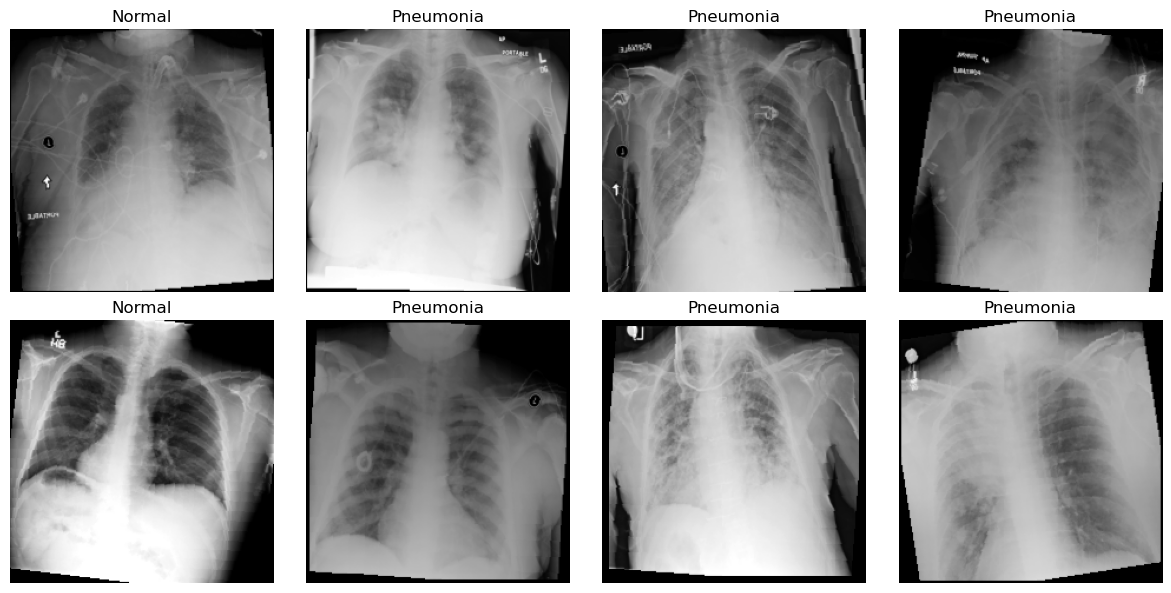

In [15]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

LOAD SWIN TRANSFORMER MODEL

In [16]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=2
)

model = model.to(device)
print("Model loaded:", MODEL_NAME)

Model loaded: swin_tiny_patch4_window7_224


LOSS FUNCTION + OPTIMIZER + SCHEDULER

In [17]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

TRAINING FUNCTION

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

VALIDATION FUNCTION

In [19]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

FULL TRAINING LOOP

In [20]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, MODEL_PATH)
        print("Best model saved.")

print("Training finished.")


Epoch [1/10]


Validation: 100%|██████████████████████████████████████████████████████████████████████████| 251/251 [00:54<00:00,  4.63it/s]


Train Loss: 0.4108 | Train Acc: 0.6969
Val Loss  : 0.5023 | Val Acc  : 0.7040
Best model saved.

Epoch [2/10]


Validation: 100%|██████████████████████████████████████████████████████████████████████████| 251/251 [00:54<00:00,  4.61it/s]


Train Loss: 0.3742 | Train Acc: 0.7313
Val Loss  : 0.5281 | Val Acc  : 0.7020

Epoch [3/10]


...

Train Loss: 0.2933 | Train Acc: 0.7955
Val Loss  : 0.5069 | Val Acc  : 0.6922

Epoch [9/10]


Validation: 100%|██████████████████████████████████████████████████████████████████████████| 251/251 [00:56<00:00,  4.48it/s]


Train Loss: 0.2887 | Train Acc: 0.8005
Val Loss  : 0.5000 | Val Acc  : 0.7147
Best model saved.

Epoch [10/10]


Validation: 100%|██████████████████████████████████████████████████████████████████████████| 251/251 [00:55<00:00,  4.50it/s]

Train Loss: 0.2790 | Train Acc: 0.8083
Val Loss  : 0.5260 | Val Acc  : 0.6862
Training finished.


PLOT TRAINING ACCURACY

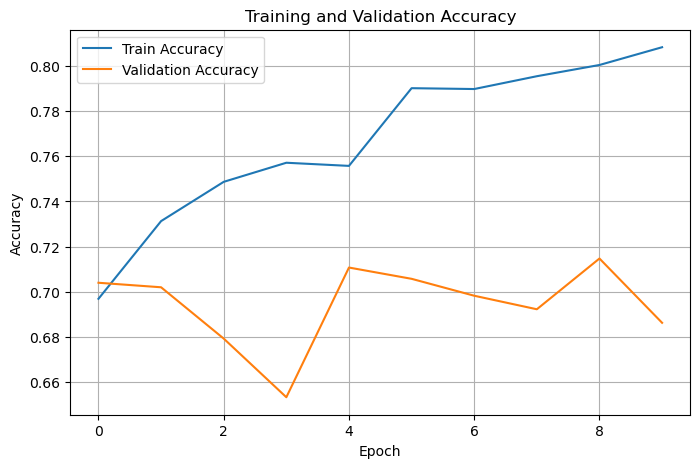

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

PLOT TRAINING LOSS

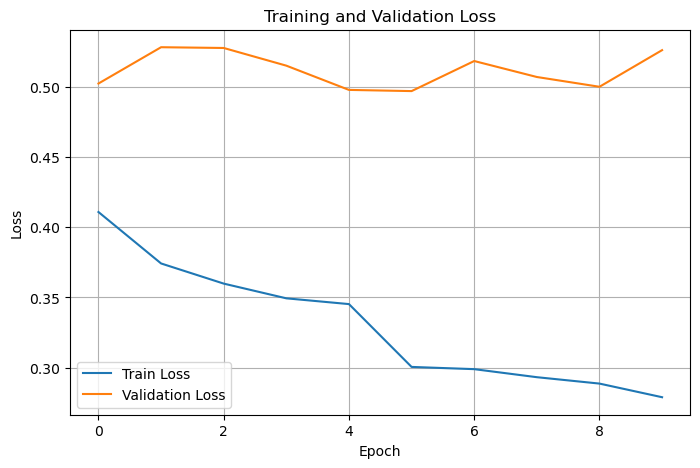

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

LOAD BEST MODEL

In [23]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Best model loaded from:", MODEL_PATH)

Best model loaded from: /Users/abdurrahman/Downloads/pneumonia_detection/output/models/best_swin_model.pth


TEST EVALUATION

In [24]:
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

Testing: 100%|█████████████████████████████████████████████████████████████████████████████| 251/251 [00:55<00:00,  4.52it/s]


 CALCULATE METRICS

In [25]:
test_acc = accuracy_score(all_test_labels, all_test_preds)
test_precision = precision_score(all_test_labels, all_test_preds)
test_recall = recall_score(all_test_labels, all_test_preds)
test_f1 = f1_score(all_test_labels, all_test_preds)

print("Test Accuracy :", round(test_acc, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall   :", round(test_recall, 4))
print("Test F1-Score :", round(test_f1, 4))

Test Accuracy : 0.7152
Test Precision: 0.4374
Test Recall   : 0.9213
Test F1-Score : 0.5931


CLASSIFICATION REPORT

In [26]:
report = classification_report(all_test_labels, all_test_preds, target_names=CLASS_NAMES)
print(report)

              precision    recall  f1-score   support

      Normal       0.97      0.66      0.78      3101
   Pneumonia       0.44      0.92      0.59       902

    accuracy                           0.72      4003
   macro avg       0.70      0.79      0.69      4003
weighted avg       0.85      0.72      0.74      4003



CONFUSION MATRIX

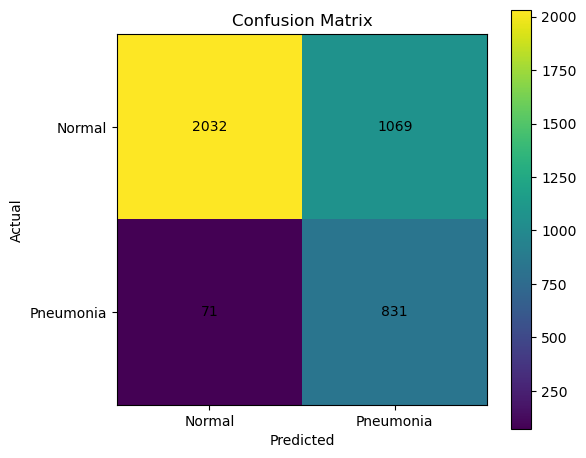

In [27]:
cm = confusion_matrix(all_test_labels, all_test_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES)
plt.yticks(tick_marks, CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Predict Pneumonia from New Image

In [28]:
def predict_new_image(image_path):

    model.eval()

    dcm = pydicom.dcmread(str(image_path))
    image = dcm.pixel_array.astype(np.float32)

    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    image_pil = Image.fromarray(image).convert("RGB")

    input_tensor = val_tfms(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap="gray")
    plt.title(f"Prediction: {CLASS_NAMES[pred]} | Confidence: {confidence:.4f}")
    plt.axis("off")
    plt.show()

    print("Prediction:", CLASS_NAMES[pred])
    print("Confidence:", confidence)

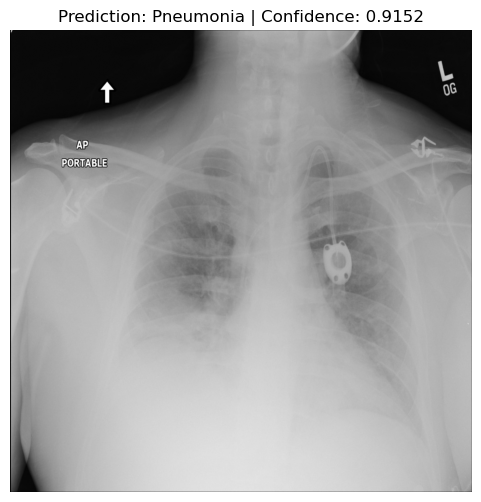

Prediction: Pneumonia
Confidence: 0.9151954054832458


In [30]:
from torchvision import transforms

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

image_path = test_df.iloc[0]["image_path"]
predict_new_image(image_path)

SAVE RESULTS TO TEXT FILE

In [31]:
with open(RESULT_TXT_PATH, "w") as f:
    f.write(f"Test Accuracy : {test_acc:.4f}\n")
    f.write(f"Test Precision: {test_precision:.4f}\n")
    f.write(f"Test Recall   : {test_recall:.4f}\n")
    f.write(f"Test F1-Score : {test_f1:.4f}\n\n")
    f.write(report)

print("Results saved to:", RESULT_TXT_PATH)

Results saved to: /Users/abdurrahman/Downloads/pneumonia_detection/output/results/test_results.txt


SINGLE IMAGE PREDICTION FUNCTION

In [32]:
def predict_single_dicom(dicom_path, model, transform, class_names, device):
    model.eval()

    dcm = pydicom.dcmread(str(dicom_path))
    image = dcm.pixel_array.astype(np.float32)
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    image = Image.fromarray(image).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        pred = torch.argmax(output, dim=1).item()

    return class_names[pred]

EXAMPLE SINGLE IMAGE PREDICTION

In [33]:
sample_path = train_df.iloc[0]["image_path"]
predicted_label = predict_single_dicom(
    dicom_path=sample_path,
    model=model,
    transform=val_test_transforms,
    class_names=CLASS_NAMES,
    device=device
)

actual_label = CLASS_NAMES[int(train_df.iloc[0]["Target"])]

print("Sample file :", sample_path.name)
print("Prediction  :", predicted_label)
print("Actual      :", actual_label)

Sample file : 80bca6c8-5cdf-4528-85d6-aa6f3336664b.dcm
Prediction  : Pneumonia
Actual      : Pneumonia
